# Quantized Flash Attention 2 with Recomputation

INT 8 Quantization mainly from [Int Flash Attention](https://arxiv.org/pdf/2409.16997).

Measure its deviation.

In [91]:
import matplotlib.pyplot as plt
import numpy as np
# import torch

SOFTMAX_QUANT_SCALE = 127
BR = 512                # Row block size
BC = 512                # Column block size
TR = 1                  # Row tile (outer loop) number
TC = 2                  # Column tile (inner loop) number
HEAD_DIM = 64
# np.random.seed(42)

## Standard Flash Attention Implementation (Ground Truth)

In [92]:
# Generate random input data
f_q = np.random.randn(BR, HEAD_DIM).astype(np.float32)
f_k = np.random.randn(TC, BC, HEAD_DIM).astype(np.float32)
f_v = np.random.randn(TC, BC, HEAD_DIM).astype(np.float32)

f_o_golden = np.zeros((BR, HEAD_DIM), dtype=np.float32)
f_l_0 = np.zeros(BR, dtype=np.float32)
f_m_0 = np.full(BR, -np.inf, dtype=np.float32)
f_l_1 = np.zeros(BR, dtype=np.float32)
f_m_1 = np.full(BR, -np.inf, dtype=np.float32)

#* Inner Loop 1
f_s = np.matmul(f_q, f_k[0].T, dtype=np.float32) / np.sqrt(HEAD_DIM)
f_m_0 = np.maximum(f_m_0, np.max(f_s, axis=1))
f_p_0 = np.exp(f_s - f_m_0[:, None])
f_l_0 = np.sum(f_p_0, axis=1)
f_o_golden = np.matmul(f_p_0, f_v[0], dtype=np.float32)

#* Inner Loop 2
f_s = np.matmul(f_q, f_k[1].T, dtype=np.float32) / np.sqrt(HEAD_DIM)
f_m_1 = np.maximum(f_m_0, np.max(f_s, axis=1))
f_p_1 = np.exp(f_s - f_m_1[:, None])
f_l_1 = f_l_0 * np.exp(f_m_0 - f_m_1) + np.sum(f_p_1, axis=1)
f_o_golden = (f_o_golden * np.exp(f_m_0 - f_m_1)[:, None] + np.matmul(f_p_1, f_v[1], dtype=np.float32)) / f_l_1[:, None]

f_o_golden

array([[ 0.06292697,  0.02570943, -0.03645328, ..., -0.0463671 ,
         0.0373535 ,  0.01039106],
       [ 0.01468283,  0.08782935, -0.10687624, ...,  0.06631579,
         0.06352871,  0.03409504],
       [-0.02297255,  0.02644623, -0.01003472, ...,  0.05105203,
        -0.01031924,  0.09115643],
       ...,
       [ 0.09784288,  0.03051275, -0.04043561, ...,  0.09731416,
        -0.05719426,  0.12329321],
       [-0.03909394,  0.07831675, -0.03294184, ...,  0.06156789,
        -0.03757779, -0.04673978],
       [ 0.04770881,  0.02952092, -0.01095935, ..., -0.00951044,
         0.02530327,  0.03904189]], shape=(512, 64))

In [93]:
def compute_golden_output(f_q, f_k, f_v):
    f_o_golden = np.zeros((BR, HEAD_DIM), dtype=np.float32)
    f_l_0 = np.zeros(BR, dtype=np.float32)
    f_m_0 = np.full(BR, -np.inf, dtype=np.float32)
    f_l_1 = np.zeros(BR, dtype=np.float32)
    f_m_1 = np.full(BR, -np.inf, dtype=np.float32)

    #* Inner Loop 1
    f_s = np.matmul(f_q, f_k[0].T, dtype=np.float32) / np.sqrt(HEAD_DIM)
    f_m_0 = np.maximum(f_m_0, np.max(f_s, axis=1))
    f_p_0 = np.exp(f_s - f_m_0[:, None])
    f_l_0 = np.sum(f_p_0, axis=1)
    f_o_golden = np.matmul(f_p_0, f_v[0], dtype=np.float32)

    #* Inner Loop 2
    f_s = np.matmul(f_q, f_k[1].T, dtype=np.float32) / np.sqrt(HEAD_DIM)
    f_m_1 = np.maximum(f_m_0, np.max(f_s, axis=1))
    f_p_1 = np.exp(f_s - f_m_1[:, None])
    f_l_1 = f_l_0 * np.exp(f_m_0 - f_m_1) + np.sum(f_p_1, axis=1)
    f_o_golden = (f_o_golden * np.exp(f_m_0 - f_m_1)[:, None] + np.matmul(f_p_1, f_v[1], dtype=np.float32)) / f_l_1[:, None]
    return f_o_golden

## Recomputation without Quantization

The first block is implemented in standard attention due to the lack of former `m, l`

In [94]:
f_o_recom = np.zeros((BR, HEAD_DIM), dtype=np.float32)
f_l_0 = np.zeros(BR, dtype=np.float32)
f_m_0 = np.full(BR, -np.inf, dtype=np.float32)
f_l_1 = np.zeros(BR, dtype=np.float32)
f_m_1 = np.full(BR, -np.inf, dtype=np.float32)

#* Inner Loop 1: Standard Flash Attention
f_s = np.matmul(f_q, f_k[0].T, dtype=np.float32) / np.sqrt(HEAD_DIM)
f_m_0 = np.maximum(f_m_0, np.max(f_s, axis=1))
f_p_0 = np.exp(f_s - f_m_0[:, None])
f_l_0 = np.sum(f_p_0, axis=1)
f_o_recom = np.matmul(f_p_0, f_v[0], dtype=np.float32)

#* Inner Loop 2: Perform recomputation here
f_s = np.matmul(f_q, f_k[1].T, dtype=np.float32) / np.sqrt(HEAD_DIM)

f_p_1_fake = np.exp(f_s - f_m_0[:, None])  # Fake f_p_1 for recomputation
f_o_recom_fake = np.matmul(f_p_1_fake, f_v[1], dtype=np.float32)  # Fake output for recomputation

f_m_1 = np.maximum(f_m_0, np.max(f_s, axis=1))
f_p_1 = np.exp(f_s - f_m_1[:, None])    # The real f_p_1
c = np.exp(f_m_0 - f_m_1)               # The correction factor

f_l_1 = f_l_0 * c + np.sum(f_p_1, axis=1)
f_o_recom = (f_o_recom + f_o_recom_fake) * c[:, None] / f_l_1[:, None]

f_o_recom

array([[ 0.06292697,  0.02570943, -0.03645328, ..., -0.0463671 ,
         0.0373535 ,  0.01039106],
       [ 0.01468284,  0.08782934, -0.10687624, ...,  0.06631577,
         0.06352871,  0.03409504],
       [-0.02297256,  0.02644625, -0.01003472, ...,  0.051052  ,
        -0.01031926,  0.09115645],
       ...,
       [ 0.09784288,  0.03051275, -0.04043561, ...,  0.09731415,
        -0.05719426,  0.1232932 ],
       [-0.03909394,  0.07831675, -0.03294185, ...,  0.06156789,
        -0.03757779, -0.04673978],
       [ 0.04770881,  0.02952092, -0.01095935, ..., -0.00951044,
         0.02530327,  0.0390419 ]], shape=(512, 64))

In [95]:
def recomputation_without_quant(f_q, f_k, f_v):
    f_o_recom = np.zeros((BR, HEAD_DIM), dtype=np.float32)
    f_l_0 = np.zeros(BR, dtype=np.float32)
    f_m_0 = np.full(BR, -np.inf, dtype=np.float32)
    f_l_1 = np.zeros(BR, dtype=np.float32)
    f_m_1 = np.full(BR, -np.inf, dtype=np.float32)

    #* Inner Loop 1: Standard Flash Attention
    f_s = np.matmul(f_q, f_k[0].T, dtype=np.float32) / np.sqrt(HEAD_DIM)
    f_m_0 = np.maximum(f_m_0, np.max(f_s, axis=1))
    f_p_0 = np.exp(f_s - f_m_0[:, None])
    f_l_0 = np.sum(f_p_0, axis=1)
    f_o_recom = np.matmul(f_p_0, f_v[0], dtype=np.float32)

    #* Inner Loop 2: Perform recomputation here
    f_s = np.matmul(f_q, f_k[1].T, dtype=np.float32) / np.sqrt(HEAD_DIM)

    f_p_1_fake = np.exp(f_s - f_m_0[:, None])  # Fake f_p_1 for recomputation
    f_o_recom_fake = np.matmul(f_p_1_fake, f_v[1], dtype=np.float32)  # Fake output for recomputation

    f_m_1 = np.maximum(f_m_0, np.max(f_s, axis=1))
    f_p_1 = np.exp(f_s - f_m_1[:, None])    # The real f_p_1
    c = np.exp(f_m_0 - f_m_1)               # The correction factor

    f_l_1 = f_l_0 * c + np.sum(f_p_1, axis=1)
    f_o_recom = (f_o_recom + f_o_recom_fake) * c[:, None] / f_l_1[:, None]
    return f_o_recom

## Quantization without recompute

In [96]:
# Prepare some functions
def quantize_to_int8(tensor: np.ndarray,
                     clip_max,
                     quant_range=SOFTMAX_QUANT_SCALE):
    scale = quant_range / clip_max
    min_bound = -quant_range
    max_bound = quant_range
    outputs = np.clip((tensor.astype(np.float32) * scale).round(), min_bound, max_bound)
    quant_tensor = outputs.astype(np.int8)
    return quant_tensor

In [97]:
q_max = np.max(np.abs(f_q), axis=1, keepdims=True)
k_max = np.max(np.abs(f_k), axis=2, keepdims=True)
# Query, Key沿Token Level量化
f_v_merged = f_v.reshape(-1, HEAD_DIM)
v_max = np.max(np.abs(f_v_merged), axis=0, keepdims=True)
# Value沿Head Dim量化，同时因为是全局量，所以无需分块
i8_q = quantize_to_int8(f_q, q_max)
i8_k = quantize_to_int8(f_k, k_max)
i8_v = quantize_to_int8(f_v, v_max)
print(f"i8_q shape: {i8_q.shape}, i8_k shape: {i8_k.shape}, i8_v shape: {i8_v.shape}")
print(f"q_max shape: {q_max.shape}, k_max shape: {k_max.shape}, v_max shape: {v_max.shape}")

i8_q shape: (512, 64), i8_k shape: (2, 512, 64), i8_v shape: (2, 512, 64)
q_max shape: (512, 1), k_max shape: (2, 512, 1), v_max shape: (1, 64)


In [98]:
f_o_quant = np.zeros((BR, HEAD_DIM), dtype=np.float32)

f_l_0 = np.zeros(BR, dtype=np.float32)
f_m_0 = np.full(BR, -np.inf, dtype=np.float32)

f_l_1 = np.zeros(BR, dtype=np.float32)
f_m_1 = np.full(BR, -np.inf, dtype=np.float32)

#* Inner Loop 1
i32_s = np.matmul(i8_q, i8_k[0].T, dtype=np.int32)
f_s = (i32_s * q_max/127 * k_max[0].T/127).astype(np.float32) / np.sqrt(HEAD_DIM)

f_m_0 = np.maximum(f_m_0, np.max(f_s, axis=1))
f_p_0 = np.exp(f_s - f_m_0[:, None])
i8_p_0 = quantize_to_int8(f_p_0, 1)

f_l_0 = np.sum(i8_p_0, axis=1).astype(np.float32)
i8_o_quant = np.matmul(i8_p_0, i8_v[0], dtype=np.float32)

#* Inner Loop 2
i32_s = np.matmul(i8_q, i8_k[1].T, dtype=np.int32)
f_s = (i32_s * q_max/127 * k_max[1].T/127).astype(np.float32) / np.sqrt(HEAD_DIM) # Dequantize

f_m_1 = np.maximum(f_m_0, np.max(f_s, axis=1))
f_p_1 = np.exp(f_s - f_m_1[:, None])
i8_p_1 = quantize_to_int8(f_p_1, 1)

f_l_1 = f_l_0 * np.exp(f_m_0 - f_m_1) + np.sum(i8_p_1, axis=1).astype(np.float32)
f_o_quant = (i8_o_quant * np.exp(f_m_0 - f_m_1)[:, None] + np.matmul(i8_p_1, i8_v[1], dtype=np.float32)) * v_max / 127 / f_l_1[:, None]

f_o_quant

array([[ 0.06187754,  0.02531295, -0.03643132, ..., -0.04681025,
         0.03742177,  0.01111318],
       [ 0.01469147,  0.08872741, -0.10776559, ...,  0.0651379 ,
         0.06342708,  0.03338456],
       [-0.02313248,  0.02544563, -0.0104388 , ...,  0.05117682,
        -0.01026817,  0.09067017],
       ...,
       [ 0.09851986,  0.03068497, -0.0396526 , ...,  0.09922832,
        -0.05828486,  0.12579824],
       [-0.03797859,  0.07980828, -0.03125411, ...,  0.06104161,
        -0.03649977, -0.0478435 ],
       [ 0.04787386,  0.02997356, -0.01063872, ..., -0.00923322,
         0.02493316,  0.03716531]], shape=(512, 64))

In [99]:
def quant_without_recom(f_q, f_k, f_v):
    q_max = np.max(np.abs(f_q), axis=1, keepdims=True)
    k_max = np.max(np.abs(f_k), axis=2, keepdims=True)
    # Query, Key沿Token Level量化
    f_v_merged = f_v.reshape(-1, HEAD_DIM)
    v_max = np.max(np.abs(f_v_merged), axis=0, keepdims=True)
    # Value沿Head Dim量化，同时因为是全局量，所以无需分块
    i8_q = quantize_to_int8(f_q, q_max)
    i8_k = quantize_to_int8(f_k, k_max)
    i8_v = quantize_to_int8(f_v, v_max)
    # print(f"i8_q shape: {i8_q.shape}, i8_k shape: {i8_k.shape}, i8_v shape: {i8_v.shape}")
    # print(f"q_max shape: {q_max.shape}, k_max shape: {k_max.shape}, v_max shape: {v_max.shape}")

    f_o_quant = np.zeros((BR, HEAD_DIM), dtype=np.float32)

    f_l_0 = np.zeros(BR, dtype=np.float32)
    f_m_0 = np.full(BR, -np.inf, dtype=np.float32)

    f_l_1 = np.zeros(BR, dtype=np.float32)
    f_m_1 = np.full(BR, -np.inf, dtype=np.float32)

    #* Inner Loop 1
    i32_s = np.matmul(i8_q, i8_k[0].T, dtype=np.int32)
    f_s = (i32_s * q_max/127 * k_max[0].T/127).astype(np.float32) / np.sqrt(HEAD_DIM)

    f_m_0 = np.maximum(f_m_0, np.max(f_s, axis=1))
    f_p_0 = np.exp(f_s - f_m_0[:, None])
    i8_p_0 = quantize_to_int8(f_p_0, 1)

    f_l_0 = np.sum(i8_p_0, axis=1).astype(np.float32)
    i8_o_quant = np.matmul(i8_p_0, i8_v[0], dtype=np.float32)

    #* Inner Loop 2
    i32_s = np.matmul(i8_q, i8_k[1].T, dtype=np.int32)
    f_s = (i32_s * q_max/127 * k_max[1].T/127).astype(np.float32) / np.sqrt(HEAD_DIM) # Dequantize

    f_m_1 = np.maximum(f_m_0, np.max(f_s, axis=1))
    f_p_1 = np.exp(f_s - f_m_1[:, None])
    i8_p_1 = quantize_to_int8(f_p_1, 1)

    f_l_1 = f_l_0 * np.exp(f_m_0 - f_m_1) + np.sum(i8_p_1, axis=1).astype(np.float32)
    f_o_quant = (i8_o_quant * np.exp(f_m_0 - f_m_1)[:, None] + np.matmul(i8_p_1, i8_v[1], dtype=np.float32)) * v_max / 127 / f_l_1[:, None]

    return f_o_quant

## Quantized Recompute (Method 1)

设置保守量化因子进行宽范围量化

In [100]:
SIGMA = 0.3 # 保守量化因子

In [101]:
f_o_quant_recom = np.zeros((BR, HEAD_DIM), dtype=np.float32)

f_l_0 = np.zeros(BR, dtype=np.float32)
f_m_0 = np.full(BR, -np.inf, dtype=np.float32)

f_l_1 = np.zeros(BR, dtype=np.float32)
f_m_1 = np.full(BR, -np.inf, dtype=np.float32)

#* Inner Loop 1: Standard Attention
i32_s = np.matmul(i8_q, i8_k[0].T, dtype=np.int32)
f_s = (i32_s * q_max/127 * k_max[0].T/127).astype(np.float32) / np.sqrt(HEAD_DIM)

f_m_0 = np.maximum(f_m_0, np.max(f_s, axis=1))
f_p_0 = np.exp(f_s - f_m_0[:, None])
i8_p_0 = quantize_to_int8(f_p_0, 1)

f_l_0 = np.sum(i8_p_0, axis=1).astype(np.float32)
i8_o_quant_recom = np.matmul(i8_p_0, i8_v[0], dtype=np.float32)

#* Inner Loop 2: Recompute
i32_s = np.matmul(i8_q, i8_k[1].T, dtype=np.int32)
f_s = (i32_s * q_max/127 * k_max[1].T/127).astype(np.float32) / np.sqrt(HEAD_DIM)           # Dequantize

f_p_1_fake = np.exp(f_s - f_m_0[:, None])
print(np.max(f_p_1_fake))

i8_p_1_fake = quantize_to_int8(f_p_1_fake, 1/SIGMA)                     # Quantize
f_o_quant_recom_fake = np.matmul(i8_p_1_fake, i8_v[1], dtype=np.float32)  # Fake compute

f_m_1 = np.maximum(f_m_0, np.max(f_s, axis=1))
f_p_1 = np.exp(f_s - f_m_1[:, None])
print(np.max(f_p_1))
i8_p_1 = quantize_to_int8(f_p_1, 1)
c = np.exp(f_m_0 - f_m_1)              # The correction factor

f_l_1 = f_l_0 * c + np.sum(i8_p_1, axis=1).astype(np.float32)

f_o_quant_recom = ((i8_o_quant_recom + f_o_quant_recom_fake / SIGMA) * c[:, None]) / f_l_1[:, None] * v_max / 127
f_o_quant_recom

4.483201278289967
1.0


array([[ 0.0638903 ,  0.0262952 , -0.03811266, ..., -0.04912212,
         0.04004094,  0.01136962],
       [ 0.01573745,  0.09003493, -0.10880062, ...,  0.06314246,
         0.06273074,  0.03454192],
       [-0.02150787,  0.0284891 , -0.01143587, ...,  0.05012879,
        -0.01104714,  0.09350376],
       ...,
       [ 0.09816434,  0.02516669, -0.04589823, ...,  0.1005362 ,
        -0.05914588,  0.12146065],
       [-0.03171791,  0.07842158, -0.03143375, ...,  0.05842186,
        -0.0283343 , -0.042181  ],
       [ 0.04885411,  0.02715828, -0.00801263, ..., -0.00861748,
         0.02532217,  0.0355075 ]], shape=(512, 64))

In [102]:
def quant_with_recomputation(f_q, f_k, f_v):
    q_max = np.max(np.abs(f_q), axis=1, keepdims=True)
    k_max = np.max(np.abs(f_k), axis=2, keepdims=True)
    # Query, Key沿Token Level量化
    f_v_merged = f_v.reshape(-1, HEAD_DIM)
    v_max = np.max(np.abs(f_v_merged), axis=0, keepdims=True)
    # Value沿Head Dim量化，同时因为是全局量，所以无需分块
    i8_q = quantize_to_int8(f_q, q_max)
    i8_k = quantize_to_int8(f_k, k_max)
    i8_v = quantize_to_int8(f_v, v_max)
        
    f_o_quant_recom = np.zeros((BR, HEAD_DIM), dtype=np.float32)

    f_l_0 = np.zeros(BR, dtype=np.float32)
    f_m_0 = np.full(BR, -np.inf, dtype=np.float32)

    f_l_1 = np.zeros(BR, dtype=np.float32)
    f_m_1 = np.full(BR, -np.inf, dtype=np.float32)

    #* Inner Loop 1: Standard Attention
    i32_s = np.matmul(i8_q, i8_k[0].T, dtype=np.int32)
    f_s = (i32_s * q_max/127 * k_max[0].T/127).astype(np.float32) / np.sqrt(HEAD_DIM)

    f_m_0 = np.maximum(f_m_0, np.max(f_s, axis=1))
    f_p_0 = np.exp(f_s - f_m_0[:, None])
    i8_p_0 = quantize_to_int8(f_p_0, 1)

    f_l_0 = np.sum(i8_p_0, axis=1).astype(np.float32)
    i8_o_quant_recom = np.matmul(i8_p_0, i8_v[0], dtype=np.float32)

    #* Inner Loop 2: Recompute
    i32_s = np.matmul(i8_q, i8_k[1].T, dtype=np.int32)
    f_s = (i32_s * q_max/127 * k_max[1].T/127).astype(np.float32) / np.sqrt(HEAD_DIM)           # Dequantize

    f_p_1_fake = np.exp(f_s - f_m_0[:, None])
    # print(np.max(f_p_1_fake))

    i8_p_1_fake = quantize_to_int8(f_p_1_fake, 1/SIGMA)                     # Quantize
    f_o_quant_recom_fake = np.matmul(i8_p_1_fake, i8_v[1], dtype=np.float32)  # Fake compute

    f_m_1 = np.maximum(f_m_0, np.max(f_s, axis=1))
    f_p_1 = np.exp(f_s - f_m_1[:, None])
    # print(np.max(f_p_1))
    i8_p_1 = quantize_to_int8(f_p_1, 1)
    c = np.exp(f_m_0 - f_m_1)              # The correction factor

    f_l_1 = f_l_0 * c + np.sum(i8_p_1, axis=1).astype(np.float32)

    f_o_quant_recom = ((i8_o_quant_recom + f_o_quant_recom_fake / SIGMA) * c[:, None]) / f_l_1[:, None] * v_max / 127
    return f_o_quant_recom

## Quantized Recompute (Method 2)

把被截位的部分保存起来后续进行补偿

即总体思路是，既然大于我在量化时预定的最大值的部分会被截断，那我就先把这一部分保存起来，即$P_{compensate} = \max(P_{fake} - max, 0)$

之后，再在输出进行补偿：$O_{compensated} = P_{fake}\cdot V + P_{compensate} \cdot V$

这个算法事实上可以和Method 1结合起来

In [103]:
f_o_quant_compensate = np.zeros((BR, HEAD_DIM), dtype=np.float32)

f_l_0 = np.zeros(BR, dtype=np.float32)
f_m_0 = np.full(BR, -np.inf, dtype=np.float32)

f_l_1 = np.zeros(BR, dtype=np.float32)
f_m_1 = np.full(BR, -np.inf, dtype=np.float32)

#* Inner Loop 1: Standard Attention
i32_s = np.matmul(i8_q, i8_k[0].T, dtype=np.int32)
f_s = (i32_s * q_max/127 * k_max[0].T/127).astype(np.float32) / np.sqrt(HEAD_DIM)

f_m_0 = np.maximum(f_m_0, np.max(f_s, axis=1))
f_p_0 = np.exp(f_s - f_m_0[:, None])
i8_p_0 = quantize_to_int8(f_p_0, 1)

f_l_0 = np.sum(i8_p_0, axis=1).astype(np.float32)
i8_o_quant_recom = np.matmul(i8_p_0, i8_v[0], dtype=np.float32)

#* Inner Loop 2: Recompute
i32_s = np.matmul(i8_q, i8_k[1].T, dtype=np.int32)
f_s = (i32_s * q_max/127 * k_max[1].T/127).astype(np.float32) / np.sqrt(HEAD_DIM)           # Dequantize

f_p_1_fake = np.exp(f_s - f_m_0[:, None])
f_p_1_compensate = np.maximum(f_p_1_fake - 1, 0)                # 补偿矩阵
print(f"The maximum value of f_p_1_fake: {np.max(f_p_1_fake)}")
print(f"There are {np.where(f_p_1_fake >= 1)[1].shape[0]} elements >= 1 in f_p_1_fake of shape {f_p_1_fake.shape}")
print(f"There are {np.where(f_p_1_fake >= 2)[1].shape[0]} elements >= 2 in f_p_1_fake of shape {f_p_1_fake.shape}")

i8_p_1_fake = quantize_to_int8(f_p_1_fake, 1)                               # Quantize 仍然取缩放因子为1
i8_p_1_compensate = quantize_to_int8(f_p_1_compensate, 1)                   # Quantize the compensate matrix
f_o_quant_recom_fake = np.matmul(i8_p_1_fake, i8_v[1], dtype=np.float32)    # Fake compute
f_o_quant_recom_compensate = np.matmul(i8_p_1_compensate, i8_v[1], dtype=np.float32)  # Compensate compute

f_m_1 = np.maximum(f_m_0, np.max(f_s, axis=1))
f_p_1 = np.exp(f_s - f_m_1[:, None])
i8_p_1 = quantize_to_int8(f_p_1, 1)
c = np.exp(f_m_0 - f_m_1)              # The correction factor

f_l_1 = f_l_0 * c + np.sum(i8_p_1, axis=1).astype(np.float32)

f_o_quant_compensate = ((i8_o_quant_recom + f_o_quant_recom_fake + f_o_quant_recom_compensate) * c[:, None]) / f_l_1[:, None] * v_max / 127
f_o_quant_compensate

The maximum value of f_p_1_fake: 4.483201278289967
There are 493 elements >= 1 in f_p_1_fake of shape (512, 512)
There are 44 elements >= 2 in f_p_1_fake of shape (512, 512)


array([[ 0.06187754,  0.02531295, -0.03643132, ..., -0.04681025,
         0.03742177,  0.01111318],
       [ 0.01664099,  0.0892232 , -0.10357293, ...,  0.05879765,
         0.06469097,  0.03664874],
       [-0.02306124,  0.02473338, -0.01078954, ...,  0.05074317,
        -0.01014017,  0.09065722],
       ...,
       [ 0.09851986,  0.03068497, -0.0396526 , ...,  0.09922832,
        -0.05828486,  0.12579824],
       [-0.03797859,  0.07980828, -0.03125411, ...,  0.06104161,
        -0.03649977, -0.0478435 ],
       [ 0.04787386,  0.02997356, -0.01063872, ..., -0.00923322,
         0.02493316,  0.03716531]], shape=(512, 64))

In [104]:
def quant_with_recomputation_and_compensation(f_q, f_k, f_v):
    q_max = np.max(np.abs(f_q), axis=1, keepdims=True)
    k_max = np.max(np.abs(f_k), axis=2, keepdims=True)
    # Query, Key沿Token Level量化
    f_v_merged = f_v.reshape(-1, HEAD_DIM)
    v_max = np.max(np.abs(f_v_merged), axis=0, keepdims=True)
    # Value沿Head Dim量化，同时因为是全局量，所以无需分块
    i8_q = quantize_to_int8(f_q, q_max)
    i8_k = quantize_to_int8(f_k, k_max)
    i8_v = quantize_to_int8(f_v, v_max)
    
    f_o_quant_compensate = np.zeros((BR, HEAD_DIM), dtype=np.float32)

    f_l_0 = np.zeros(BR, dtype=np.float32)
    f_m_0 = np.full(BR, -np.inf, dtype=np.float32)

    f_l_1 = np.zeros(BR, dtype=np.float32)
    f_m_1 = np.full(BR, -np.inf, dtype=np.float32)

    #* Inner Loop 1: Standard Attention
    i32_s = np.matmul(i8_q, i8_k[0].T, dtype=np.int32)
    f_s = (i32_s * q_max/127 * k_max[0].T/127).astype(np.float32) / np.sqrt(HEAD_DIM)

    f_m_0 = np.maximum(f_m_0, np.max(f_s, axis=1))
    f_p_0 = np.exp(f_s - f_m_0[:, None])
    i8_p_0 = quantize_to_int8(f_p_0, 1)

    f_l_0 = np.sum(i8_p_0, axis=1).astype(np.float32)
    i8_o_quant_recom = np.matmul(i8_p_0, i8_v[0], dtype=np.float32)

    #* Inner Loop 2: Recompute
    i32_s = np.matmul(i8_q, i8_k[1].T, dtype=np.int32)
    f_s = (i32_s * q_max/127 * k_max[1].T/127).astype(np.float32) / np.sqrt(HEAD_DIM)           # Dequantize

    f_p_1_fake = np.exp(f_s - f_m_0[:, None])
    f_p_1_compensate = np.maximum(f_p_1_fake - 1, 0)                # 补偿矩阵
    # print(f"The maximum value of f_p_1_fake: {np.max(f_p_1_fake)}")
    # print(f"There are {np.where(f_p_1_fake >= 1)[1].shape[0]} elements >= 1 in f_p_1_fake of shape {f_p_1_fake.shape}")
    # print(f"There are {np.where(f_p_1_fake >= 2)[1].shape[0]} elements >= 2 in f_p_1_fake of shape {f_p_1_fake.shape}")

    i8_p_1_fake = quantize_to_int8(f_p_1_fake, 1)                               # Quantize 仍然取缩放因子为1
    i8_p_1_compensate = quantize_to_int8(f_p_1_compensate, 1)                   # Quantize the compensate matrix
    f_o_quant_recom_fake = np.matmul(i8_p_1_fake, i8_v[1], dtype=np.float32)    # Fake compute
    f_o_quant_recom_compensate = np.matmul(i8_p_1_compensate, i8_v[1], dtype=np.float32)  # Compensate compute

    f_m_1 = np.maximum(f_m_0, np.max(f_s, axis=1))
    f_p_1 = np.exp(f_s - f_m_1[:, None])
    i8_p_1 = quantize_to_int8(f_p_1, 1)
    c = np.exp(f_m_0 - f_m_1)              # The correction factor

    f_l_1 = f_l_0 * c + np.sum(i8_p_1, axis=1).astype(np.float32)

    f_o_quant_compensate = ((i8_o_quant_recom + f_o_quant_recom_fake + f_o_quant_recom_compensate) * c[:, None]) / f_l_1[:, None] * v_max / 127
    return f_o_quant_compensate

## Quantized Recompute (Combine 2 Methods)

In [105]:
SIGMA = 0.8 # 对这种算法重新设置一个保守量化因子

In [106]:
f_o_quant_combined = np.zeros((BR, HEAD_DIM), dtype=np.float32)

f_l_0 = np.zeros(BR, dtype=np.float32)
f_m_0 = np.full(BR, -np.inf, dtype=np.float32)

f_l_1 = np.zeros(BR, dtype=np.float32)
f_m_1 = np.full(BR, -np.inf, dtype=np.float32)

#* Inner Loop 1: Standard Attention
i32_s = np.matmul(i8_q, i8_k[0].T, dtype=np.int32)
f_s = (i32_s * q_max/127 * k_max[0].T/127).astype(np.float32) / np.sqrt(HEAD_DIM)

f_m_0 = np.maximum(f_m_0, np.max(f_s, axis=1))
f_p_0 = np.exp(f_s - f_m_0[:, None])
i8_p_0 = quantize_to_int8(f_p_0, 1)

f_l_0 = np.sum(i8_p_0, axis=1).astype(np.float32)
i8_o_quant_recom = np.matmul(i8_p_0, i8_v[0], dtype=np.float32)

#* Inner Loop 2: Recompute
i32_s = np.matmul(i8_q, i8_k[1].T, dtype=np.int32)
f_s = (i32_s * q_max/127 * k_max[1].T/127).astype(np.float32) / np.sqrt(HEAD_DIM)           # Dequantize

f_p_1_fake = np.exp(f_s - f_m_0[:, None])
f_p_1_compensate = np.maximum(f_p_1_fake - 1/SIGMA, 0)                # 补偿矩阵
print(f"The maximum value of f_p_1_fake: {np.max(f_p_1_fake)}")
print(f"There are {np.where(f_p_1_fake >= 1/SIGMA)[1].shape[0]} elements >= {1/SIGMA} in f_p_1_fake of shape {f_p_1_fake.shape}")
print(f"There are {np.where(f_p_1_fake >= 2/SIGMA)[1].shape[0]} elements >= {2/SIGMA} in f_p_1_fake of shape {f_p_1_fake.shape}")

i8_p_1_fake = quantize_to_int8(f_p_1_fake, 1/SIGMA)                               # Quantize 仍然取缩放因子为1
i8_p_1_compensate = quantize_to_int8(f_p_1_compensate, 1/SIGMA)                   # Quantize the compensate matrix
f_o_quant_recom_fake = np.matmul(i8_p_1_fake, i8_v[1], dtype=np.float32)    # Fake compute
f_o_quant_recom_compensate = np.matmul(i8_p_1_compensate, i8_v[1], dtype=np.float32)  # Compensate compute

f_m_1 = np.maximum(f_m_0, np.max(f_s, axis=1))
f_p_1 = np.exp(f_s - f_m_1[:, None])
i8_p_1 = quantize_to_int8(f_p_1, 1)
c = np.exp(f_m_0 - f_m_1)              # The correction factor

f_l_1 = f_l_0 * c + np.sum(i8_p_1, axis=1).astype(np.float32)

f_o_quant_combined = ((i8_o_quant_recom + f_o_quant_recom_fake/SIGMA + f_o_quant_recom_compensate/SIGMA) * c[:, None]) / f_l_1[:, None] * v_max / 127
f_o_quant_combined

The maximum value of f_p_1_fake: 4.483201278289967
There are 256 elements >= 1.25 in f_p_1_fake of shape (512, 512)
There are 22 elements >= 2.5 in f_p_1_fake of shape (512, 512)


array([[ 0.06316558,  0.02456414, -0.03748162, ..., -0.0464233 ,
         0.0375471 ,  0.00991993],
       [ 0.01724699,  0.08989198, -0.10585247, ...,  0.06363229,
         0.06333357,  0.03379429],
       [-0.02322224,  0.02553434, -0.00962579, ...,  0.04956837,
        -0.01018019,  0.0906552 ],
       ...,
       [ 0.0998261 ,  0.02643478, -0.03899689, ...,  0.10059754,
        -0.05951852,  0.12574775],
       [-0.03695707,  0.07993677, -0.03144498, ...,  0.06215096,
        -0.03540262, -0.04700269],
       [ 0.04797661,  0.02845218, -0.01275834, ..., -0.01000717,
         0.02328971,  0.0370761 ]], shape=(512, 64))

## Visualize

### Per Token

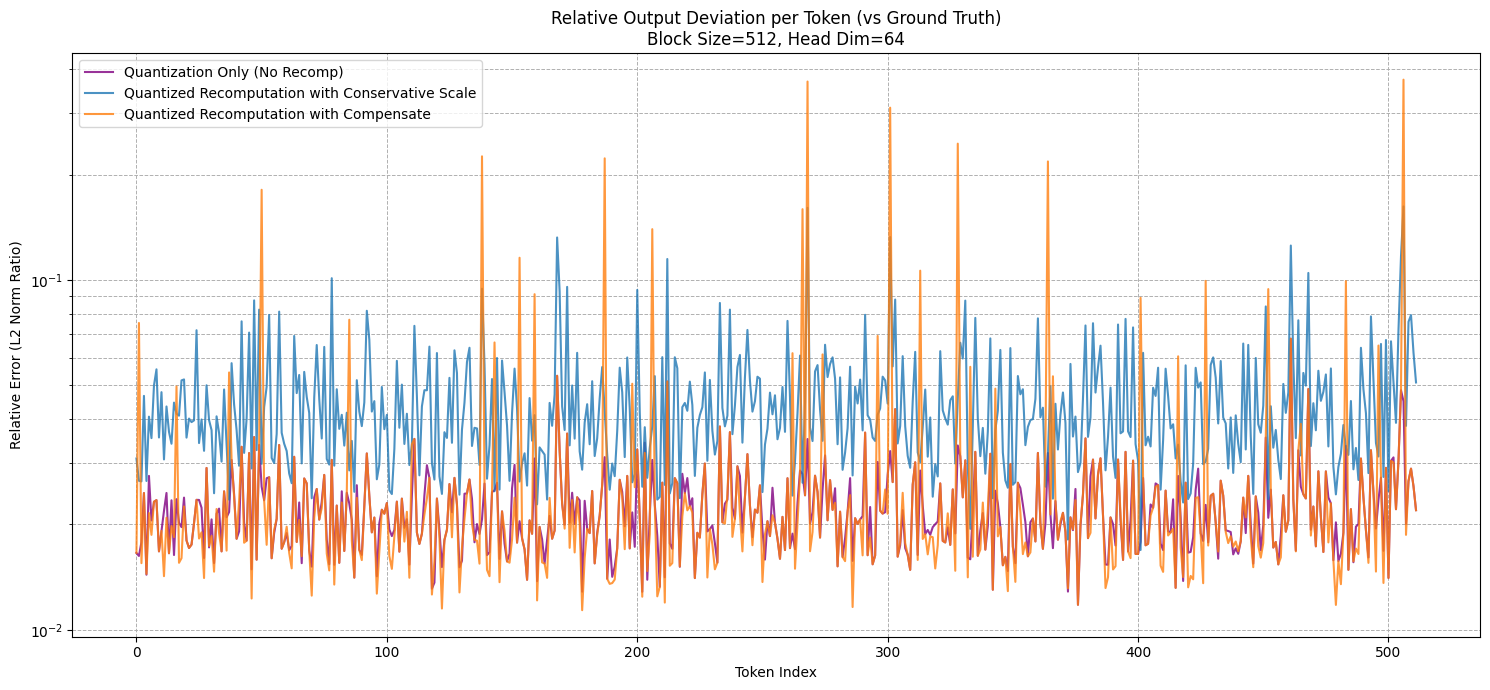

Mean Relative Error (Float Recomp): 0.000015%
Mean Relative Error (Quant Only):   2.201707%
Mean Relative Error (Quant Recomp with Conservative Scale): 4.440526%
Mean Relative Error (Quant Recomp with Compensate): 2.748778%


In [119]:
plt.figure(figsize=(15, 7))

# 1. 计算相对误差 (Relative Error)
# 先计算 Ground Truth 每个 Token 的 L2 范数作为基准
norm_golden = np.linalg.norm(f_o_golden, axis=1)
# 防止除以零，设置一个极小值下界
norm_golden = np.maximum(norm_golden, 1e-6)

# 计算每个 Token 的相对误差: ||O_golden - O_target|| / ||O_golden||
rel_err_recom_float = np.linalg.norm(f_o_golden - f_o_recom, axis=1) / norm_golden
rel_err_quant = np.linalg.norm(f_o_golden - f_o_quant, axis=1) / norm_golden
rel_err_quant_recom = np.linalg.norm(f_o_golden - f_o_quant_recom, axis=1) / norm_golden
rel_err_quant_compensate = np.linalg.norm(f_o_golden - f_o_quant_compensate, axis=1) / norm_golden

# 2. 绘制曲线
x_axis = np.arange(BR)

# plt.plot(x_axis, rel_err_recom_float, label='Float Recompute (No Quant)', alpha=0.6)
plt.plot(x_axis, rel_err_quant, label='Quantization Only (No Recomp)', alpha=0.8, color='purple')
plt.plot(x_axis, rel_err_quant_recom, label='Quantized Recomputation with Conservative Scale', alpha=0.8)
plt.plot(x_axis, rel_err_quant_compensate, label='Quantized Recomputation with Compensate', alpha=0.8)

# 3. 设置图表信息
plt.title(f'Relative Output Deviation per Token (vs Ground Truth)\nBlock Size={BR}, Head Dim={HEAD_DIM}')
plt.xlabel('Token Index')
plt.ylabel('Relative Error (L2 Norm Ratio)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.7)
plt.yscale('log') # 保持对数坐标，观察量级差异
plt.tight_layout()

plt.show()

# 打印平均相对误差统计 (Mean Relative Error)
print(f"Mean Relative Error (Float Recomp): {np.mean(rel_err_recom_float):.6%}")
print(f"Mean Relative Error (Quant Only):   {np.mean(rel_err_quant):.6%}")
print(f"Mean Relative Error (Quant Recomp with Conservative Scale): {np.mean(rel_err_quant_recom):.6%}")
print(f"Mean Relative Error (Quant Recomp with Compensate): {np.mean(rel_err_quant_compensate):.6%}")

### Per Sequence Length

Starting evaluation for sequence lengths: [128, 256, 512, 1024, 2048, 4096, 8192, 10240]
128
(128, 64)
Finished length 128
256
(256, 64)
Finished length 256
512
(512, 64)
Finished length 512
1024
(1024, 64)
Finished length 1024
2048
(2048, 64)
Finished length 2048
4096
(4096, 64)
Finished length 4096
8192
(8192, 64)
Finished length 8192
10240
(10240, 64)
Finished length 10240


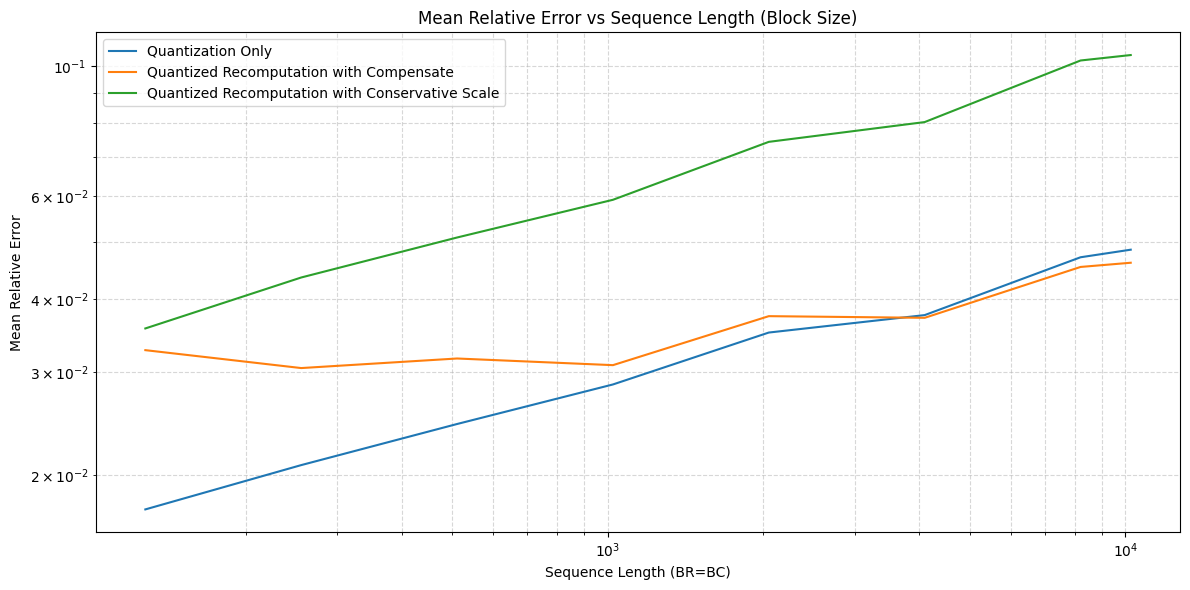

In [120]:
# 实验设置
seq_lengths = [128, 256, 512, 1024, 2048, 4096, 8192, 10240]
err_recomp_list = []
err_quant_list = []
err_quant_recomp_list = []
err_compensate_list = []

print(f"Starting evaluation for sequence lengths: {seq_lengths}")

for l in seq_lengths:
    BR = l
    BC = l
    TC = 2
    TR = 1
    HEAD_DIM = 64
    
    # 生成数据
    f_q = np.random.randn(BR, HEAD_DIM).astype(np.float32)
    f_k = np.random.randn(TC, BC, HEAD_DIM).astype(np.float32)
    f_v = np.random.randn(TC, BC, HEAD_DIM).astype(np.float32)
    
    # Ground Truth
    f_o_golden = compute_golden_output(f_q, f_k, f_v)
    norm_golden = np.linalg.norm(f_o_golden, axis=1)
    norm_golden = np.maximum(norm_golden, 1e-6)
    
    def calc_mean_rel_err(f_o_target):
        err = np.linalg.norm(f_o_golden - f_o_target, axis=1) / norm_golden
        return np.mean(err)
    
    #* 0. Recompute Only
    f_o = recomputation_without_quant(f_q, f_k, f_v)
    err_recomp_list.append(calc_mean_rel_err(f_o))
    
    #* 1. Quant Only
    f_o = quant_without_recom(f_q, f_k, f_v)
    err_quant_list.append(calc_mean_rel_err(f_o))
    
    #* 2. Quant Recomp (SIGMA=0.3)
    SIGMA = 0.3 # 设置全局变量供函数使用
    f_o = quant_with_recomputation(f_q, f_k, f_v)
    err_quant_recomp_list.append(calc_mean_rel_err(f_o))
    
    #* 3. Quant Compensate
    f_o = quant_with_recomputation_and_compensation(f_q, f_k, f_v)
    err_compensate_list.append(calc_mean_rel_err(f_o))
        
    print(f"Finished length {l}")

# 绘图
plt.figure(figsize=(12, 6))

plt.plot(seq_lengths, err_quant_list, label='Quantization Only')

# plt.plot(seq_lengths, err_recomp_list, label='Recomputation Only')

plt.plot(seq_lengths, err_compensate_list, label='Quantized Recomputation with Compensate')

plt.plot(seq_lengths, err_quant_recomp_list, label='Quantized Recomputation with Conservative Scale')

plt.title('Mean Relative Error vs Sequence Length (Block Size)')
plt.xlabel('Sequence Length (BR=BC)')
plt.ylabel('Mean Relative Error')
plt.xscale('log') # 使用对数坐标轴
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()